## Can a computer learn if we are going to detect gravitational waves?
 In order to decide if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our **selection effects**.

 In observational astronomy, this is known as **Malmquist bias** and was first formulated in 1922.

 The goal here is to machine-learn the **LIGO detectability**: can we predict if a gravitational-wave source will be detected?



In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import h5py
import os

In [2]:
from sklearn.model_selection import train_test_split, cross_val_predict, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.manifold import Isomap
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

In [3]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
path = "data_files/"
file_path = os.path.join(path, "sample_2e7_design_precessing_higherordermodes_3detectors.h5")

In [5]:
# Exploring the datafile categories
names = []
with h5py.File(file_path, 'r') as f:
  for key in f.keys():
    names.append(key)

In [6]:
print(names)

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [7]:
# Extrapolating data
data = []
with h5py.File(file_path, 'r') as f:
  for key in names:
    temp_data = f[key][:]
    data.append(temp_data)

In [8]:
# Creating a dataframe for more visibility
table = pd.DataFrame(np.array(data).T, columns=names)

This dataset contains simulated gravitational-wave signals from merging black holes.

In particular, each source has the following features:
1. **mtot**: the total mass of the binary
2. **q**: the mass ratio
3. **chi1x, chi1y, chi1z, chi2x, chi2y, chi2z**: the components of the black-hole spins in a suitable reference frame
4. **ra, dec**: the location of the source in the sky
5. **iota**: the inclination of the orbital plane
6. **psi**: the polarization angle (gravitational waves have two polarization states much like light)
7. **z**: the redshift

The detectability is defined using the **snr** (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network.

All you need to know now is that we threshold the snr values and assume that LIGO will (not) see a source if snr > 12 (snr < 12).

The resulting 0-1 labels are reported in the **det** attribute in the dataset.

In [9]:
table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0.0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0.0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0.0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0.0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1.0,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0.0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0.0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0.0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0.0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


**Tasks**

- You can downsample the data for debugging purposes.
- You can also use only some of the features.
- Plot ROC curves.
- Try to reduce the dimensionality of the dataset with a PCA-type algorithm to ease the classification problem (optional).
- Using the same data, we could run a regressor on snr instead of a classifier on det. We can then threshold the predictions instead of tresholding the data (optional).

Let's see who gets the highest completeness and/or the smallest contamination (on a validation set, of course, careful with overfitting here).

In [10]:
sel_table = table.sample(int(5e4), random_state=123)

In [11]:
sel_table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
15191020,-0.394590,-0.175546,-0.099537,-0.224426,0.309381,0.005351,0.216419,0.0,1.548212,717.176541,1.004169,0.567814,3.004350,1.678397,1.578780
2592642,-0.218814,0.106123,0.281787,-0.009301,0.215415,0.017141,-0.666551,0.0,0.683097,866.154911,2.447854,0.831828,0.363030,2.429325,2.246367
16549869,-0.229644,-0.144448,-0.049129,-0.125606,-0.088156,0.786711,-0.977480,0.0,1.955051,226.322524,0.265396,0.194682,-0.275282,2.130516,0.937704
3532938,0.714416,0.074388,-0.445331,-0.058945,-0.259140,-0.110248,0.061129,0.0,1.487609,138.497285,2.397598,0.938140,-0.905637,0.816376,3.875390
17264223,0.832338,-0.402064,0.065214,0.108816,0.295538,0.036017,0.226165,0.0,1.515643,238.632797,0.373274,0.464283,-3.043462,1.484080,3.672292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11206879,0.016558,0.524274,-0.042388,-0.155179,-0.420216,-0.297930,-0.731463,0.0,1.674263,486.613932,1.246008,0.115062,0.269293,1.132570,1.541616
15162461,-0.009499,0.112694,0.001595,0.000618,-0.117563,0.115211,-0.788199,1.0,0.892809,792.124679,0.051962,0.263524,-2.860418,19.554790,0.465788
16061040,0.261437,-0.208895,-0.775742,0.009282,-0.243814,-0.566592,1.290071,0.0,1.540730,780.505624,1.009726,0.206396,0.878188,0.812361,2.736835
12964725,0.069348,-0.168166,0.099645,-0.093535,-0.008401,0.123537,-0.318963,1.0,1.671553,544.680519,0.285778,0.902985,0.443281,22.774501,0.192163


In [12]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [13]:
feature_table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,iota,mtot,psi,q,ra,z
15191020,-0.394590,-0.175546,-0.099537,-0.224426,0.309381,0.005351,0.216419,1.548212,717.176541,1.004169,0.567814,3.004350,1.578780
2592642,-0.218814,0.106123,0.281787,-0.009301,0.215415,0.017141,-0.666551,0.683097,866.154911,2.447854,0.831828,0.363030,2.246367
16549869,-0.229644,-0.144448,-0.049129,-0.125606,-0.088156,0.786711,-0.977480,1.955051,226.322524,0.265396,0.194682,-0.275282,0.937704
3532938,0.714416,0.074388,-0.445331,-0.058945,-0.259140,-0.110248,0.061129,1.487609,138.497285,2.397598,0.938140,-0.905637,3.875390
17264223,0.832338,-0.402064,0.065214,0.108816,0.295538,0.036017,0.226165,1.515643,238.632797,0.373274,0.464283,-3.043462,3.672292
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11206879,0.016558,0.524274,-0.042388,-0.155179,-0.420216,-0.297930,-0.731463,1.674263,486.613932,1.246008,0.115062,0.269293,1.541616
15162461,-0.009499,0.112694,0.001595,0.000618,-0.117563,0.115211,-0.788199,0.892809,792.124679,0.051962,0.263524,-2.860418,0.465788
16061040,0.261437,-0.208895,-0.775742,0.009282,-0.243814,-0.566592,1.290071,1.540730,780.505624,1.009726,0.206396,0.878188,2.736835
12964725,0.069348,-0.168166,0.099645,-0.093535,-0.008401,0.123537,-0.318963,1.671553,544.680519,0.285778,0.902985,0.443281,0.192163


In [14]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [15]:
print(X_names)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']


In [16]:
print(X.shape)
print(y.shape)

(50000, 13)
(50000,)


In [17]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.25, random_state=42)

In [18]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

#### PCA

In [19]:
# dimensionality reduction with PCA
pca = PCA(n_components=0.95)
X_pca_train = pca.fit_transform(X_std_train)
X_pca_test = pca.transform(X_std_test)
print(pca.n_components_)

13


In [20]:
print("All components (n = {:.0f}) explain {:.3f} of the variance in the data.".format(pca.n_components_, sum(pca.explained_variance_ratio_)))

All components (n = 13) explain 1.000 of the variance in the data.


In [21]:
for i in range(len(pca.components_)):
  print("Eigenvector n.",i)
  print(" + ".join("%.5f %s" % (value, name) for value, name in zip(pca.components_[i], X_names)))
  print("\n")

Eigenvector n. 0
-0.19205 chi1x + 0.05587 chi1y + 0.18452 chi1z + 0.45899 chi2x + 0.24311 chi2y + 0.48001 chi2z + -0.01434 dec + -0.37206 iota + -0.32119 mtot + -0.19432 psi + 0.15371 q + 0.17267 ra + -0.30459 z


Eigenvector n. 1
-0.00182 chi1x + 0.47479 chi1y + -0.35541 chi1z + 0.23766 chi2x + 0.42660 chi2y + -0.16423 chi2z + 0.27266 dec + -0.30154 iota + 0.25391 mtot + 0.12915 psi + 0.10479 q + -0.03231 ra + 0.35267 z


Eigenvector n. 2
-0.52123 chi1x + -0.09005 chi1y + 0.10811 chi1z + -0.16679 chi2x + 0.19879 chi2y + -0.20497 chi2z + -0.07847 dec + -0.12798 iota + -0.02383 mtot + 0.36910 psi + -0.40436 q + 0.52563 ra + 0.00552 z


Eigenvector n. 3
-0.26374 chi1x + -0.14670 chi1y + -0.35266 chi1z + 0.07770 chi2x + -0.37784 chi2y + -0.00726 chi2z + -0.16161 dec + -0.19208 iota + -0.42160 mtot + 0.43197 psi + 0.35861 q + -0.16926 ra + 0.22604 z


Eigenvector n. 4
0.18860 chi1x + -0.14042 chi1y + -0.14163 chi1z + 0.07379 chi2x + -0.13109 chi2y + 0.08545 chi2z + -0.20158 dec + -0.37894 

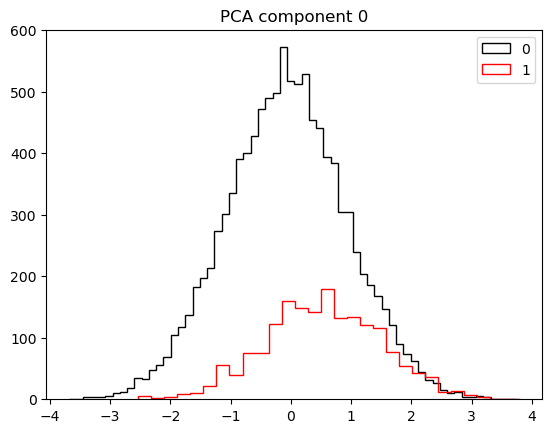

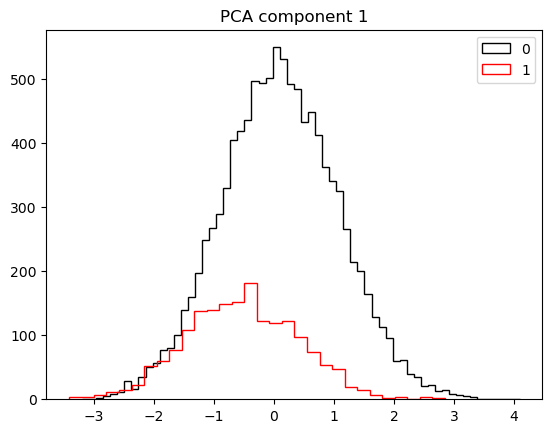

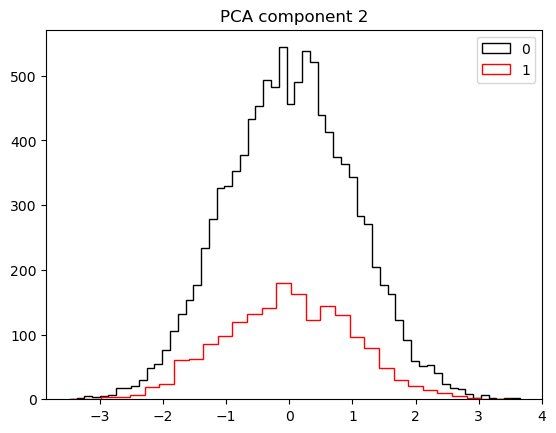

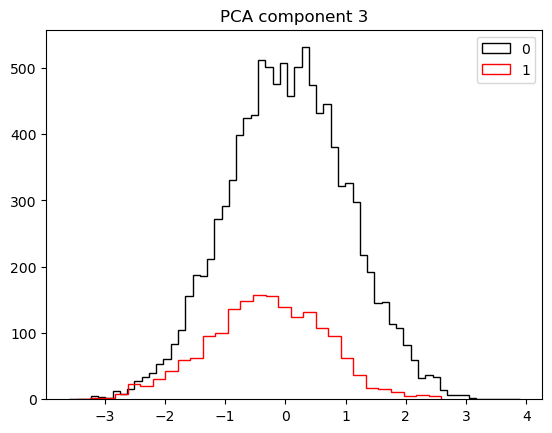

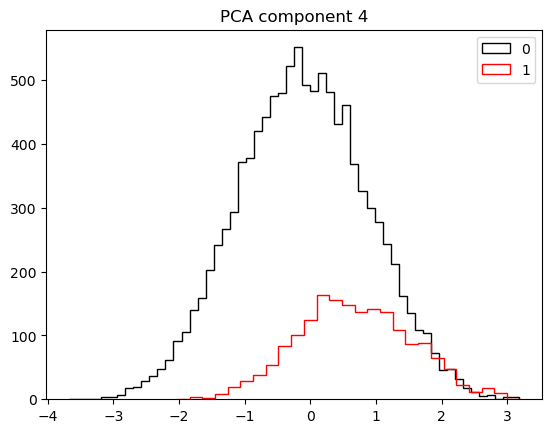

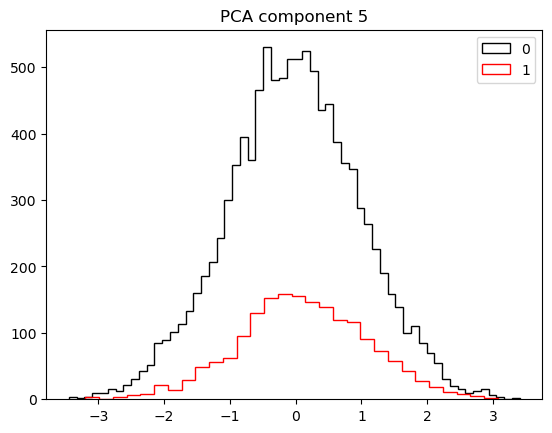

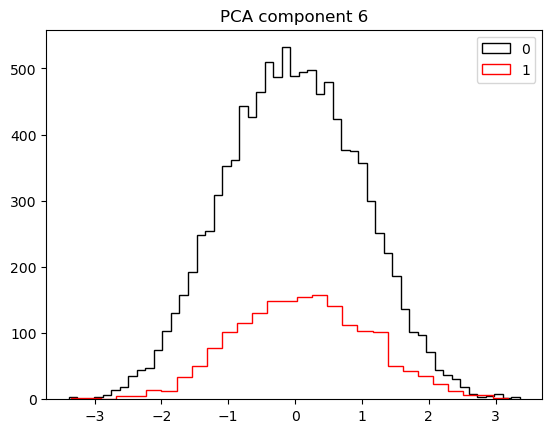

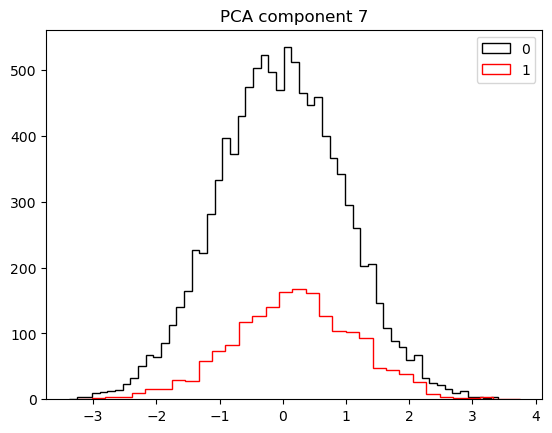

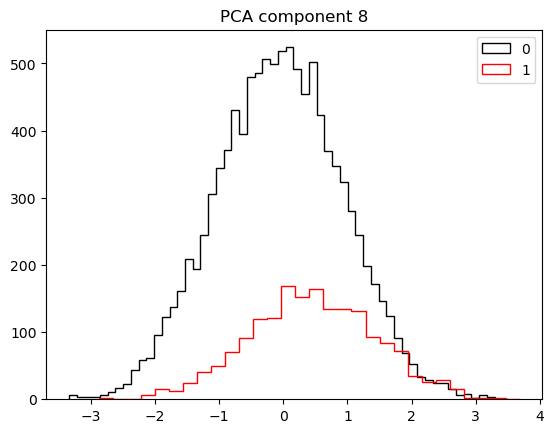

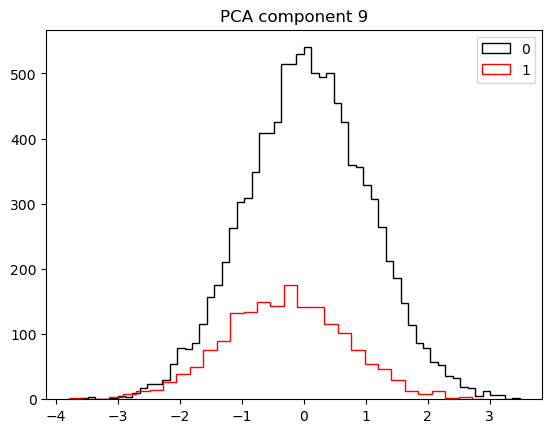

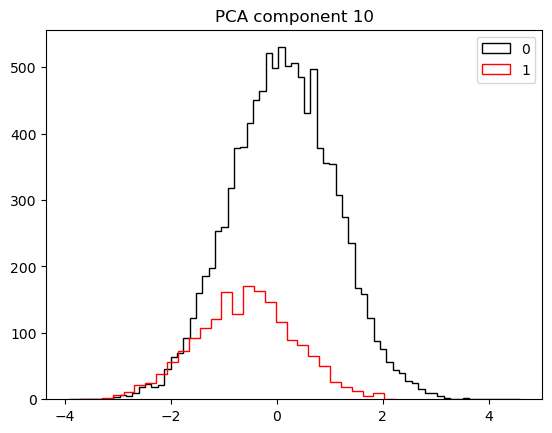

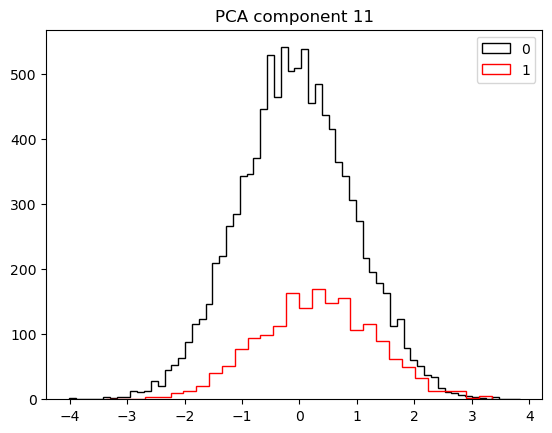

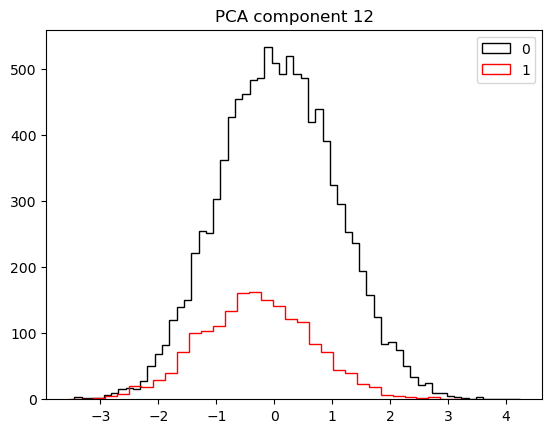

In [22]:
for i in range(pca.n_components_):
  plt.hist(X_pca_test[:, i].flatten()[y_test==0], bins="auto", histtype='step', color='black', label="0")
  plt.hist(X_pca_test[:, i].flatten()[y_test==1], bins="auto", histtype='step', color='red', label="1")
  plt.legend()
  plt.title(f"PCA component {i}")
  plt.show()
  plt.close()

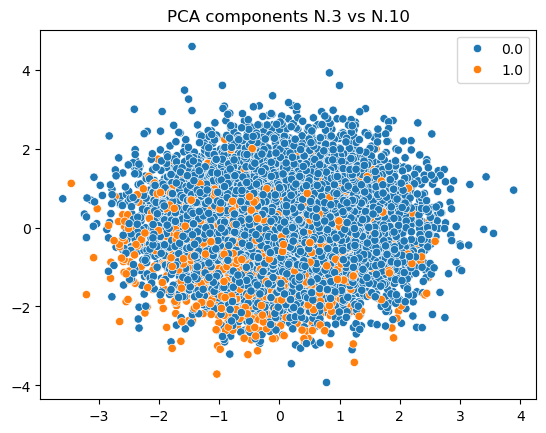

In [23]:
i, j = np.random.choice(range(pca.n_components_), 2, replace=False)
sns.scatterplot(x=X_pca_test[:, i], y=X_pca_test[:, j], hue=y_test)
plt.title(f"PCA components N.{i} vs N.{j}")
plt.show()

#### Some Classifiers

In [24]:
# Logistic Regression

# Use cross validation to tune hyperparameters such as C the regularization parameter
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=10)
grid_lr.fit(X_std_train, y_train)
C_opt = grid_lr.best_params_['C']
print(C_opt)

0.1


In [25]:
# C_opt_lr = 0.1

In [26]:
lr = LogisticRegression(C=C_opt, class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_std_train, y_train)
y_pred_lr = lr.predict(X_std_test)
y_prob_lr = lr.predict_proba(X_std_test)[:, 1]
fpr_lr, tpr_lr, thresh1_lr = roc_curve(y_test, y_prob_lr)
precision_lr, recall_lr, thresh2_lr = precision_recall_curve(y_test, y_prob_lr)

In [27]:
y_pred_lr_train = lr.predict(X_std_train)
completeness_score_lr = recall_score(y_train, y_pred_lr_train)
contamination_score_lr = 1 - precision_score(y_train, y_pred_lr_train)
print("Logistic Regression:")
print("Train completeness score: {:.3f}".format(completeness_score_lr))
print("Train contamination score: {:.3f}".format(contamination_score_lr))

Logistic Regression:
Train completeness score: 0.945
Train contamination score: 0.389


In [28]:
completeness_score_lr = recall_score(y_test, y_pred_lr)
contamination_score_lr = 1 - precision_score(y_test, y_pred_lr)
print("Logistic Regression:")
print("Test completeness score: {:.3f}".format(completeness_score_lr))
print("Test contamination score: {:.3f}".format(contamination_score_lr))

Logistic Regression:
Test completeness score: 0.954
Test contamination score: 0.399


In [29]:
# Check by hand already implemented functions
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()

In [30]:
my_recall_lr = tp/(tp+fn)
my_precision_lr = tp/(tp+fp)
print("Recall: {:.3f}".format(my_recall_lr))
print("Precision: {:.3f}".format(my_precision_lr))
print("Contamination: {:.3f}".format(1-my_precision_lr))

Recall: 0.954
Precision: 0.601
Contamination: 0.399


In [31]:
# SVM

# Use cross validation to tune hyperparameters
param_grid_svm = {'C': [0.01, 0.1, 1, 10, 100]}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, verbose=2)
grid_svm.fit(X_std_train, y_train)
C_opt = grid_svm.best_params_['C']
print(C_opt)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END .............................................C=0.01; total time=  16.9s
[CV] END .............................................C=0.01; total time=  16.3s
[CV] END .............................................C=0.01; total time=  16.5s
[CV] END .............................................C=0.01; total time=  18.6s
[CV] END .............................................C=0.01; total time=  16.4s
[CV] END ..............................................C=0.1; total time=  13.7s
[CV] END ..............................................C=0.1; total time=  13.4s
[CV] END ..............................................C=0.1; total time=  13.5s
[CV] END ..............................................C=0.1; total time=  12.5s
[CV] END ..............................................C=0.1; total time=  13.4s
[CV] END ................................................C=1; total time=   9.4s
[CV] END ........................................

In [32]:
# C_opt_svm = 1

In [33]:
svm = SVC(kernel='linear', C=C_opt, class_weight='balanced', random_state=42, probability=True)
svm.fit(X_std_train, y_train)
y_pred_svm = svm.predict(X_std_test)
y_prob_svm = svm.predict_proba(X_std_test)[:, 1]
fpr_svm, tpr_svm, thresh1_svm = roc_curve(y_test, y_prob_svm)
precision_svm, recall_svm, thresh2_svm = precision_recall_curve(y_test, y_prob_svm)

In [34]:
y_pred_svm_train = svm.predict(X_std_train)
completeness_score_svm = recall_score(y_train, y_pred_svm_train)
contamination_score_svm = 1 - precision_score(y_train, y_pred_svm_train)
print("Linear SVM:")
print("Train completeness score: {:.3f}".format(completeness_score_svm))
print("Train contamination score: {:.3f}".format(contamination_score_svm))

Linear SVM:
Train completeness score: 0.946
Train contamination score: 0.389


In [35]:
completeness_score_svm = recall_score(y_test, y_pred_svm)
contamination_score_svm = 1 - precision_score(y_test, y_pred_svm)
print("Linear SVM:")
print("Test completeness score: {:.3f}".format(completeness_score_svm))
print("Test contamination score: {:.3f}".format(contamination_score_svm))

Linear SVM:
Test completeness score: 0.955
Test contamination score: 0.400


In [36]:
# K-Nearest Neighbors

# Use cross validation to tune hyperparameters such as the number of neighbors K
param_grid_knn = {'n_neighbors': range(1, 20, 2)}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=10)
grid_knn.fit(X_std_train, y_train)
K_opt = grid_knn.best_params_['n_neighbors']
print(K_opt)

7


In [37]:
# K_opt = 7

In [38]:
# Final KNeighborsClassifier fit with tuned hyperparameter K
knc = KNeighborsClassifier(n_neighbors=K_opt, weights='distance')
knc.fit(X_std_train, y_train)
y_pred_knc = knc.predict(X_std_test)
y_prob_knc = knc.predict_proba(X_std_test)[:, 1]
fpr_knc, tpr_knc, thresh1_knc = roc_curve(y_test, y_prob_knc)
precision_knc, recall_knc, thresh2_knc = precision_recall_curve(y_test, y_prob_knc)

In [39]:
y_pred_knc_train = knc.predict(X_std_train)
completeness_score_knc = recall_score(y_train, y_pred_knc_train)
contamination_score_knc = 1 - precision_score(y_train, y_pred_knc_train)
print("K-Nearest Neighbors:")
print("Train completeness score: {:.3f}".format(completeness_score_knc))
print("Train contamination score: {:.3f}".format(contamination_score_knc))

K-Nearest Neighbors:
Train completeness score: 1.000
Train contamination score: 0.000


In [40]:
completeness_score_knc = recall_score(y_test, y_pred_knc)
contamination_score_knc = 1 - precision_score(y_test, y_pred_knc)
print("K-Nearest Neighbors:")
print("Test completeness score: {:.3f}".format(completeness_score_knc))
print("Test contamination score: {:.3f}".format(contamination_score_knc))

K-Nearest Neighbors:
Test completeness score: 0.446
Test contamination score: 0.201


In [41]:
# Check by hand already implemented functions
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knc).ravel()

In [42]:
my_recall_knc = tp/(tp+fn)
my_precision_knc = tp/(tp+fp)
print("Recall: {:.3f}".format(my_recall_knc))
print("Precision: {:.3f}".format(my_precision_knc))
print("Contamination: {:.3f}".format(1-my_precision_knc))

Recall: 0.446
Precision: 0.799
Contamination: 0.201


In [43]:
# Single Decision Tree

# Use cross validation to tune hyperparameters such as h the max depth of the tree
param_grid_dt = {'criterion': ['gini', 'entropy'], 'max_depth': range(1, 21)}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5, verbose=2)
grid_dt.fit(X_std_train, y_train)
h_opt = grid_dt.best_params_['max_depth']
print(h_opt)
criterion_opt = grid_dt.best_params_['criterion']
print(criterion_opt)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END ........................criterion=gini, max_depth=1; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=1; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=1; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=1; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=1; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=2; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=2; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=2; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=2; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=2; total time=   0.0s
[CV] END ........................criterion=gini, max_depth=3; total time=   0.1s
[CV] END ........................criterion=gini

In [44]:
# h_opt = 9
# criterion_opt = 'entropy'

In [45]:
# Final DecisionTreeClassifier fit with tuned hyperparameter h
dtc = DecisionTreeClassifier(criterion=criterion_opt, max_depth=h_opt, class_weight='balanced', random_state=42)
dtc.fit(X_std_train, y_train)
y_pred_dtc = dtc.predict(X_std_test)
y_prob_dtc = dtc.predict_proba(X_std_test)[:, 1]
fpr_dtc, tpr_dtc, thresh1_dtc = roc_curve(y_test, y_prob_dtc)
precision_dtc, recall_dtc, thresh2_dtc = precision_recall_curve(y_test, y_prob_dtc)

In [46]:
y_pred_dtc_train = dtc.predict(X_std_train)
completeness_score_dtc = recall_score(y_train, y_pred_dtc_train)
contamination_score_dtc = 1 - precision_score(y_train, y_pred_dtc_train)
print("Decision Tree:")
print("Train completeness score: {:.3f}".format(completeness_score_dtc))
print("Train contamination score: {:.3f}".format(contamination_score_dtc))

Decision Tree:
Train completeness score: 0.989
Train contamination score: 0.248


In [47]:
completeness_score_dtc = recall_score(y_test, y_pred_dtc)
contamination_score_dtc = 1 - precision_score(y_test, y_pred_dtc)
print("Decision Tree:")
print("Test completeness score: {:.3f}".format(completeness_score_dtc))
print("Test contamination score: {:.3f}".format(contamination_score_dtc))

Decision Tree:
Test completeness score: 0.949
Test contamination score: 0.287


In [48]:
# Check by hand already implemented functions
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dtc).ravel()

In [49]:
my_recall_dtc = tp/(tp+fn)
my_precision_dtc = tp/(tp+fp)
print("Recall: {:.3f}".format(my_recall_dtc))
print("Precision: {:.3f}".format(my_precision_dtc))
print("Contamination: {:.3f}".format(1-my_precision_dtc))

Recall: 0.949
Precision: 0.713
Contamination: 0.287


In [50]:
# Random Forest (an ensemble of Decision Trees)
rfc = RandomForestClassifier(criterion=criterion_opt, max_depth=h_opt, class_weight='balanced', random_state=42, verbose=2)
rfc.fit(X_std_train, y_train)
y_pred_rfc = rfc.predict(X_std_test)
y_prob_rfc = rfc.predict_proba(X_std_test)[:, 1]
fpr_rfc, tpr_rfc, thresh1_rfc = roc_curve(y_test, y_prob_rfc)
precision_rfc, recall_rfc, thresh2_rfc = precision_recall_curve(y_test, y_prob_rfc)

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    4.0s


building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


In [51]:
y_pred_rfc_train = rfc.predict(X_std_train)
completeness_score_rfc = recall_score(y_train, y_pred_rfc_train)
contamination_score_rfc = 1 - precision_score(y_train, y_pred_rfc_train)
print("Decision Tree:")
print("Train completeness score: {:.3f}".format(completeness_score_rfc))
print("Train contamination score: {:.3f}".format(contamination_score_rfc))

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


Decision Tree:
Train completeness score: 0.982
Train contamination score: 0.262


In [52]:
completeness_score_rfc = recall_score(y_test, y_pred_rfc)
contamination_score_rfc = 1 - precision_score(y_test, y_pred_rfc)
print("Decision Tree:")
print("Test completeness score: {:.3f}".format(completeness_score_rfc))
print("Test contamination score: {:.3f}".format(contamination_score_rfc))

Decision Tree:
Test completeness score: 0.961
Test contamination score: 0.299


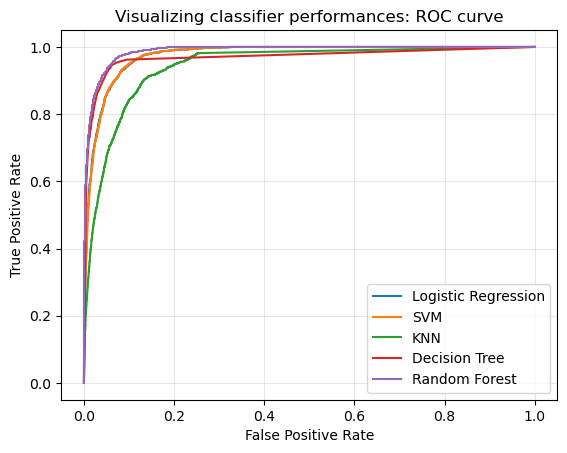

In [53]:
# Plotting performances
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_knc, tpr_knc, label="KNN")
plt.plot(fpr_dtc, tpr_dtc, label="Decision Tree")
plt.plot(fpr_rfc, tpr_rfc, label="Random Forest")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

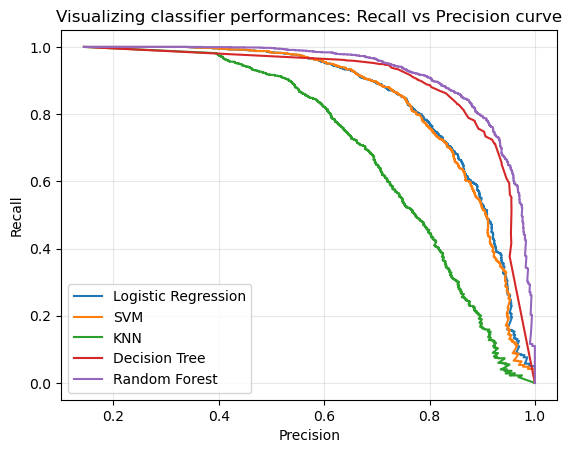

In [54]:
plt.plot(precision_lr, recall_lr, label="Logistic Regression")
plt.plot(precision_svm, recall_svm, label="SVM")
plt.plot(precision_knc, recall_knc, label="KNN")
plt.plot(precision_dtc, recall_dtc, label="Decision Tree")
plt.plot(precision_rfc, recall_rfc, label="Random Forest")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [55]:
thresh2_lr = np.insert(thresh2_lr, 0, 0.0)

In [56]:
thresh2_svm = np.insert(thresh2_svm, 0, 0.0)

In [57]:
thresh2_knc = np.insert(thresh2_knc, 0, 0.0)

In [58]:
thresh2_dtc = np.insert(thresh2_dtc, 0, 0.0)

In [59]:
thresh2_rfc = np.insert(thresh2_rfc, 0, 0.0)

- **Low threshold:**	You predict “positive” more often → higher recall (completeness), but more false positives → lower precision (efficiency).
- **High threshold:**	You predict “positive” less often → higher precision (efficiency), but more false negatives → lower recall (completeness).

Logistic Regression
Precision at cond : 0.789
Recall at cond : 0.789
Threshold at cond : 0.846


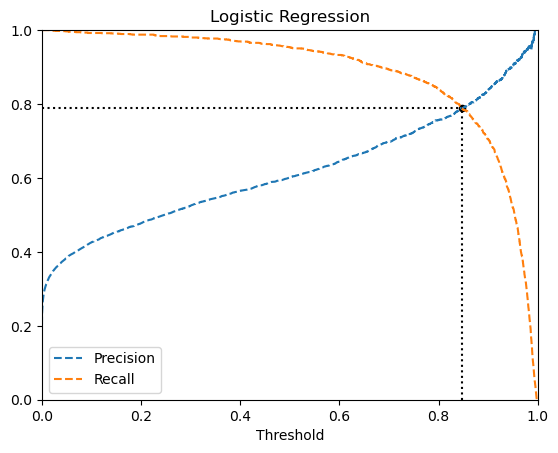

In [60]:
print("Logistic Regression")
cond_lr = np.argmax(precision_lr == recall_lr)
rec_eq = recall_lr[cond_lr]
thresh_eq = thresh2_lr[cond_lr]
prec_eq = precision_lr[cond_lr]
print("Precision at cond : {:.3f}".format(prec_eq))
print("Recall at cond : {:.3f}".format(rec_eq))
print("Threshold at cond : {:.3f}".format(thresh_eq))

plt.plot(thresh2_lr, precision_lr, "--", label="Precision")
plt.plot(thresh2_lr, recall_lr, "--", label="Recall")
plt.axvline(x=thresh_eq, color="k", linestyle=":", ymin=0, ymax=prec_eq)
plt.axhline(y=prec_eq, color='k', linestyle=':', xmin=0, xmax=thresh_eq)
plt.scatter(thresh_eq, prec_eq, color="k", marker="o", s=20)
plt.title("Logistic Regression")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower left")
plt.show()
plt.close()

Linear SVM
Precision at cond : 0.786
Recall at cond : 0.786
Threshold at cond : 0.509


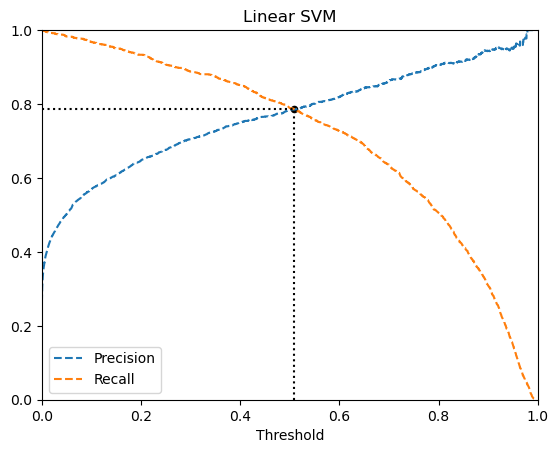

In [61]:
print("Linear SVM")
cond_svm = np.argmax(precision_svm == recall_svm)
rec_eq = recall_svm[cond_svm]
thresh_eq = thresh2_svm[cond_svm]
prec_eq = precision_svm[cond_svm]
print("Precision at cond : {:.3f}".format(prec_eq))
print("Recall at cond : {:.3f}".format(rec_eq))
print("Threshold at cond : {:.3f}".format(thresh_eq))

plt.plot(thresh2_svm, precision_svm, "--", label="Precision")
plt.plot(thresh2_svm, recall_svm, "--", label="Recall")
plt.axvline(x=thresh_eq, color="k", linestyle=":", ymin=0, ymax=prec_eq)
plt.axhline(y=prec_eq, color='k', linestyle=':', xmin=0, xmax=thresh_eq)
plt.scatter(thresh_eq, prec_eq, color="k", marker="o", s=20)
plt.title("Linear SVM")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower left")
plt.show()
plt.close()

K-Nearest Neighbors
Precision at cond : 0.686
Recall at cond : 0.686
Threshold at cond : 0.400


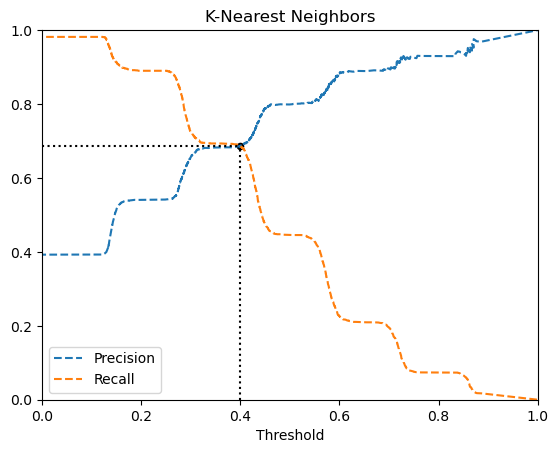

In [62]:
print("K-Nearest Neighbors")
cond_knc = np.argmax(abs(precision_knc-recall_knc) == min(abs(precision_knc-recall_knc)))
rec_eq = recall_knc[cond_knc]
thresh_eq = thresh2_knc[cond_knc]
prec_eq = precision_knc[cond_knc]
print("Precision at cond : {:.3f}".format(prec_eq))
print("Recall at cond : {:.3f}".format(rec_eq))
print("Threshold at cond : {:.3f}".format(thresh_eq))

plt.plot(thresh2_knc, precision_knc, "--", label="Precision")
plt.plot(thresh2_knc, recall_knc, "--", label="Recall")
plt.axvline(x=thresh_eq, color="k", linestyle=":", ymin=0, ymax=prec_eq)
plt.axhline(y=prec_eq, color='k', linestyle=':', xmin=0, xmax=thresh_eq)
plt.scatter(thresh_eq, prec_eq, color="k", marker="o", s=20)
plt.title("K-Nearest Neighbors")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower left")
plt.show()
plt.close()

Decision Tree
Precision at cond : 0.851
Recall at cond : 0.834
Threshold at cond : 0.880


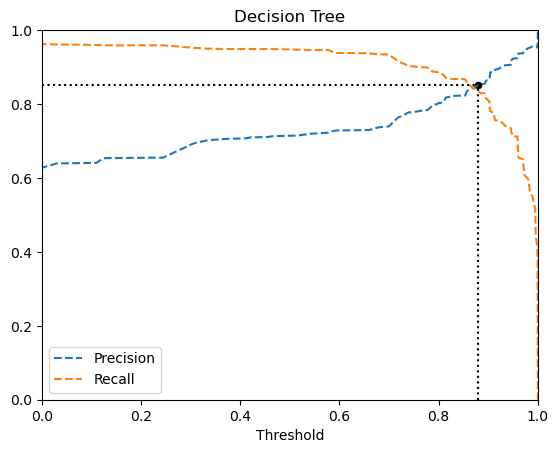

In [63]:
print("Decision Tree")
cond_dtc = np.argmax(abs(precision_dtc-recall_dtc) == min(abs(precision_dtc-recall_dtc)))
rec_eq = recall_dtc[cond_dtc]
thresh_eq = thresh2_dtc[cond_dtc]
prec_eq = precision_dtc[cond_dtc]
print("Precision at cond : {:.3f}".format(prec_eq))
print("Recall at cond : {:.3f}".format(rec_eq))
print("Threshold at cond : {:.3f}".format(thresh_eq))

plt.plot(thresh2_dtc, precision_dtc, "--", label="Precision")
plt.plot(thresh2_dtc, recall_dtc, "--", label="Recall")
plt.axvline(x=thresh_eq, color="k", linestyle=":", ymin=0, ymax=prec_eq)
plt.axhline(y=prec_eq, color='k', linestyle=':', xmin=0, xmax=thresh_eq)
plt.scatter(thresh_eq, prec_eq, color="k", marker="o", s=20)
plt.title("Decision Tree")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower left")
plt.show()
plt.close()

Random Forest
Precision at cond : 0.858
Recall at cond : 0.858
Threshold at cond : 0.741


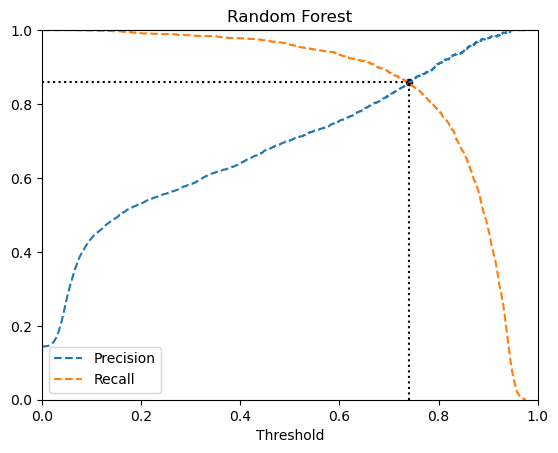

In [64]:
print("Random Forest")
cond_rfc = np.argmax(abs(precision_rfc-recall_rfc) == min(abs(precision_rfc-recall_rfc)))
rec_eq = recall_rfc[cond_rfc]
thresh_eq = thresh2_rfc[cond_rfc]
prec_eq = precision_rfc[cond_rfc]
print("Precision at cond : {:.3f}".format(prec_eq))
print("Recall at cond : {:.3f}".format(rec_eq))
print("Threshold at cond : {:.3f}".format(thresh_eq))

plt.plot(thresh2_rfc, precision_rfc, "--", label="Precision")
plt.plot(thresh2_rfc, recall_rfc, "--", label="Recall")
plt.axvline(x=thresh_eq, color="k", linestyle=":", ymin=0, ymax=prec_eq)
plt.axhline(y=prec_eq, color='k', linestyle=':', xmin=0, xmax=thresh_eq)
plt.scatter(thresh_eq, prec_eq, color="k", marker="o", s=20)
plt.title("Random Forest")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower left")
plt.show()
plt.close()